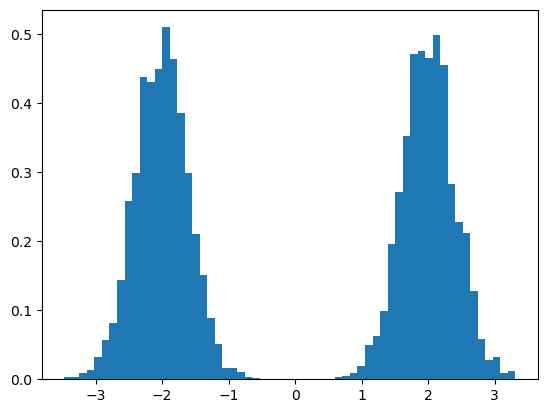

In [1]:
import numpy as np
import matplotlib.pyplot as plt

N = 5000

xk = np.concatenate([
    np.random.normal(-2,0.4,N//2),
    np.random.normal(2,0.4,N//2)
])

plt.hist(xk,bins=60,density=True)
plt.show()

In [2]:
import torch
import torch.nn as nn

In [3]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 2)  # scale + shift
        )

    def forward(self, x):
        out = self.net(x)
        scale = torch.tanh(out[:, 0:1])  # keep stable
        shift = out[:, 1:2]
        return scale, shift

In [4]:
class FlowLayer(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = Net()

    def forward(self, x):
        scale, shift = self.net(x)

        # ensure invertibility
        scale = torch.tanh(scale) * 0.9

        z = x * torch.exp(scale) + shift

        log_det = scale  # derivative of exp(scale)*x + shift

        return z, log_det

In [5]:
class Flow(nn.Module):
    def __init__(self, n_layers=6):
        super().__init__()
        self.layers = nn.ModuleList([FlowLayer() for _ in range(n_layers)])

    def forward(self, x):

        log_det_total = 0

        z = x

        for layer in self.layers:
            z, log_det = layer(z)
            log_det_total += log_det

        return z, log_det_total

In [6]:
class AffineFlow(nn.Module):

    def __init__(self):
        super().__init__()

        self.log_scale = nn.Parameter(torch.zeros(1))
        self.shift = nn.Parameter(torch.zeros(1))

    def forward(self,x):

        scale = torch.exp(self.log_scale)

        z = scale*x + self.shift

        log_det = self.log_scale

        return z, log_det

In [7]:
def loss(flow, x):

    z, log_det = flow(x)
    log_pz = -0.5 * z**2 - 0.5 * np.log(2*np.pi)

    log_px = log_pz + log_det

    return -log_px.mean()

In [8]:
# flow = AffineFlow()
flow = Flow(n_layers=6)

optimizer = torch.optim.Adam(flow.parameters(),lr=1e-2)

xt = torch.tensor(xk,dtype=torch.float32).view(-1, 1)

for epoch in range(2000):

    optimizer.zero_grad()

    l = loss(flow,xt)

    l.backward()

    optimizer.step()

    if epoch%200==0:
        print(epoch,l.item())

0 3.507819890975952
200 -2.5055811405181885
400 -2.5071489810943604
600 -2.5075833797454834
800 -2.5077965259552
1000 -2.507920026779175
1200 -2.50799822807312
1400 -2.508049726486206
1600 -2.508087635040283
1800 -2.508117198944092


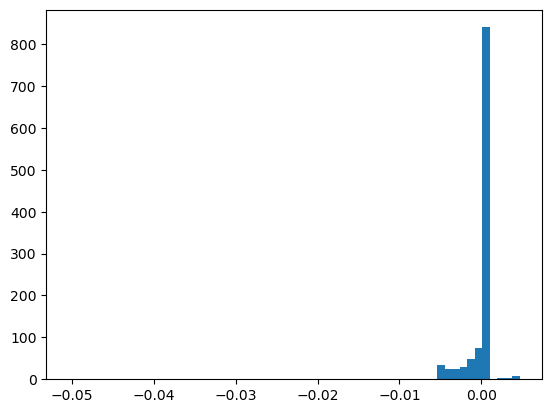

In [9]:
with torch.no_grad():

    z,_ = flow(xt)

plt.hist(z.numpy(),bins=60,density=True)
plt.show()